Importación de librerías

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import shap
 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pathlib import Path
 
plt.style.use("seaborn-v0_8")

Carga de datos

In [ ]:
PROJ_ROOT         = Path(r"C:\Users\jorge gonzalez\Documents\TFG\Proyecto")
DATA_FEATURES_DIR = PROJ_ROOT / "data" / "features" / "hotel_ttoo"
METRICS_DIR       = PROJ_ROOT / "models" / "metrics"
IMPORTANCE_DIR    = PROJ_ROOT / "models" / "importances"
PRED_DIR          = PROJ_ROOT / "models" / "predictions"
 
for d in [METRICS_DIR, IMPORTANCE_DIR, PRED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

In [31]:
files = glob.glob(os.path.join(DATA_FEATURES_DIR, "*.parquet"))
 
dfs = [pd.read_parquet(f) for f in files]
df  = pd.concat(dfs, ignore_index=True)
 
print("Shape dataset:", df.shape)
df.head()

Shape dataset: (3038, 21)


,fecha,hotel,ocup_total,is_weekend,season,rn_AL,rn_AV,rn_B,rn_C,rn_EA,...,rn_H,rn_J,rn_K,rn_L,rn_O,rn_T,rn_TH,rn_TR,rn_WEB,rn_WEL
0,2023-01-01,HOTEL_1,0.510638,1,winter,0.0,0.0,19.0,0.0,0.0,...,0.0,0.0,1.0,0.0,4.0,0.0,0.0,1.0,0.0,16.0
1,2023-01-02,HOTEL_1,0.659574,0,winter,0.0,0.0,26.0,0.0,0.0,...,0.0,0.0,2.0,0.0,4.0,0.0,0.0,1.0,0.0,25.0
2,2023-01-03,HOTEL_1,0.627660,0,winter,0.0,0.0,24.0,0.0,0.0,...,2.0,0.0,2.0,0.0,4.0,0.0,0.0,1.0,0.0,20.0
3,2023-01-04,HOTEL_1,0.670213,0,winter,0.0,0.0,29.0,0.0,0.0,...,9.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,0.0,15.0
4,2023-01-05,HOTEL_1,0.691489,0,winter,0.0,0.0,27.0,0.0,0.0,...,19.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,0.0,10.0


Preprocesamiento

In [32]:
df["fecha"] = pd.to_datetime(df["fecha"], unit="ms")
df = df.sort_values(["hotel", "fecha"]).dropna()
df = pd.get_dummies(df, columns=["season"], drop_first=True)
 
print("Dataset limpio:", df.shape)

Dataset limpio: (3038, 23)


Selección de vVariables (ajustado)

In [33]:
target       = "ocup_total"
CALENDAR_COLS = ["is_weekend"]
 
def select_causal_features(df_cols):
    return [
        c for c in df_cols
        if c == "is_weekend"
        or c.startswith("season_")
        or c.startswith("rn_")
    ]
 
hotels = df["hotel"].unique()

Entrenamiento del modelo


================== HOTEL_1 ==================


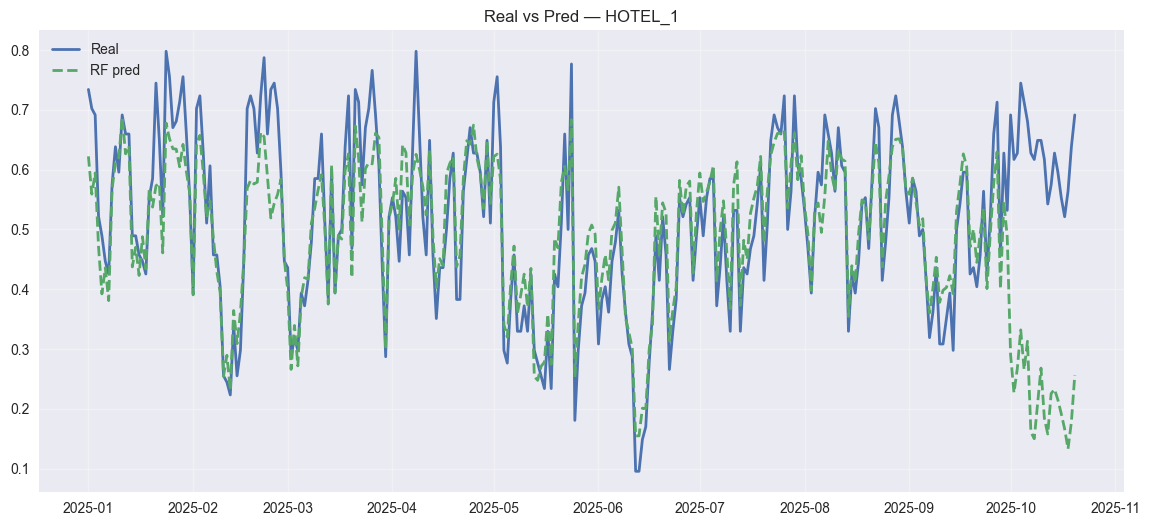

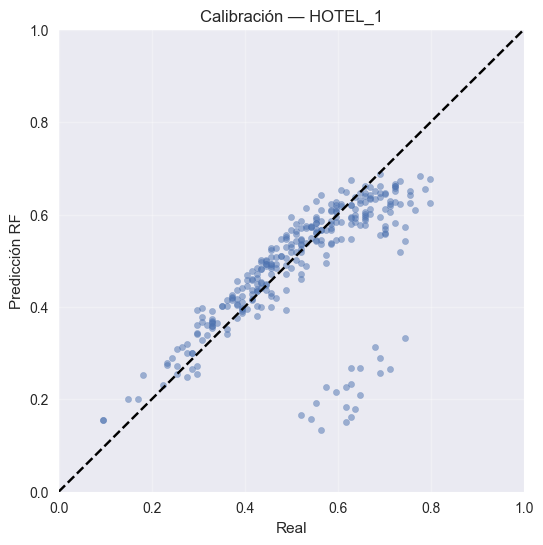

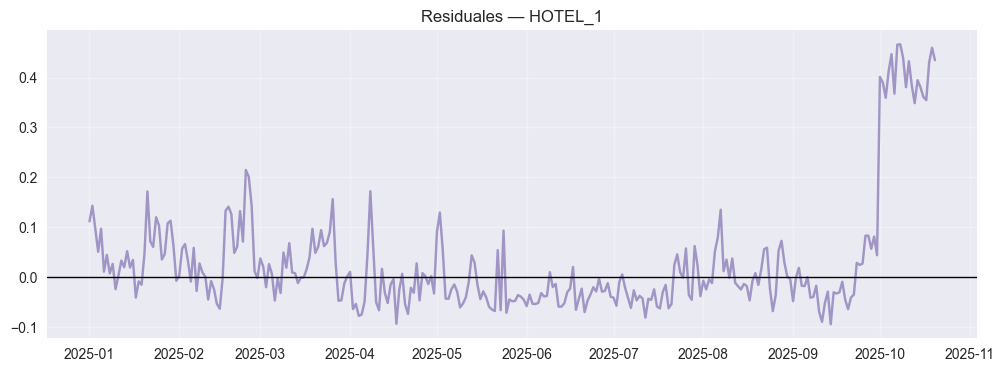

C:\Users\jorge gonzalez\AppData\Local\Temp\ipykernel_99704\3728436828.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tmp, x="is_weekend", y="abs_err", palette="Blues")


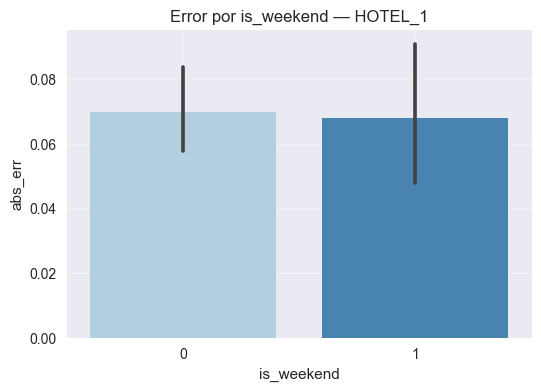


================== HOTEL_2 ==================


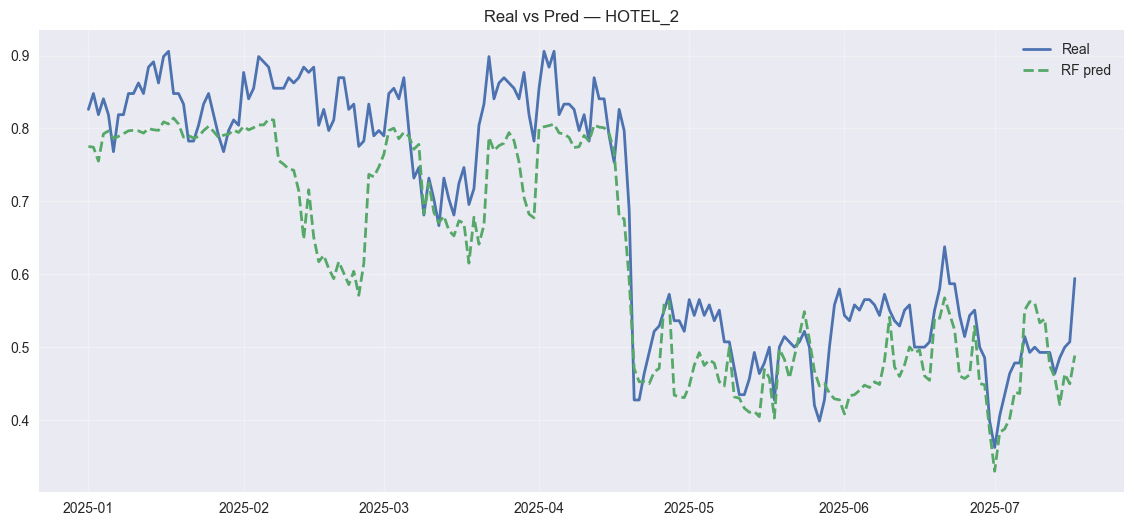

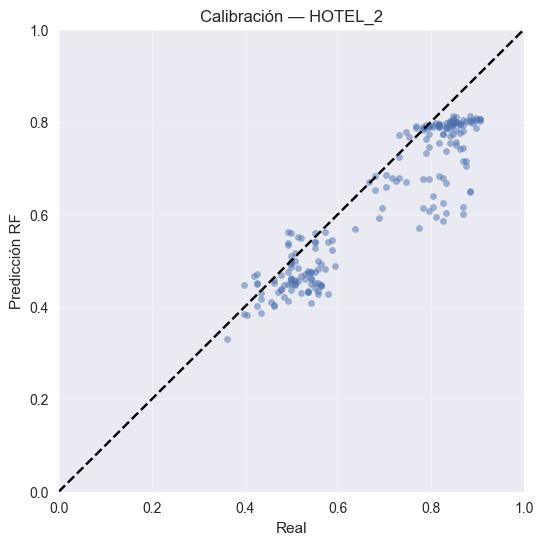

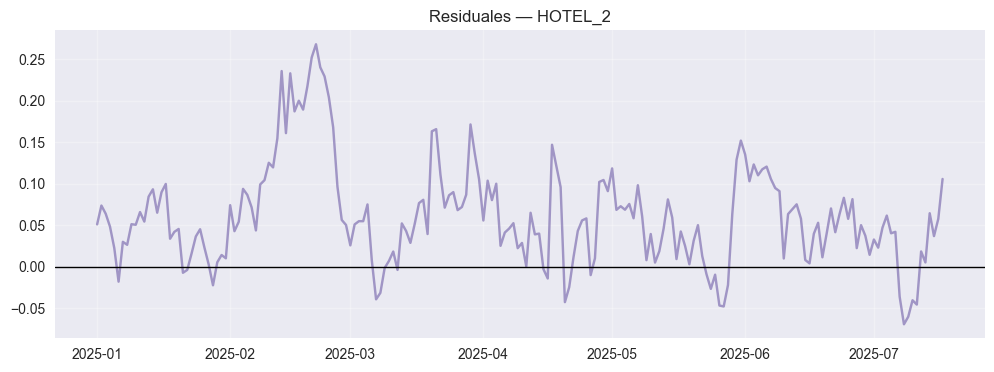

C:\Users\jorge gonzalez\AppData\Local\Temp\ipykernel_99704\3728436828.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tmp, x="is_weekend", y="abs_err", palette="Blues")


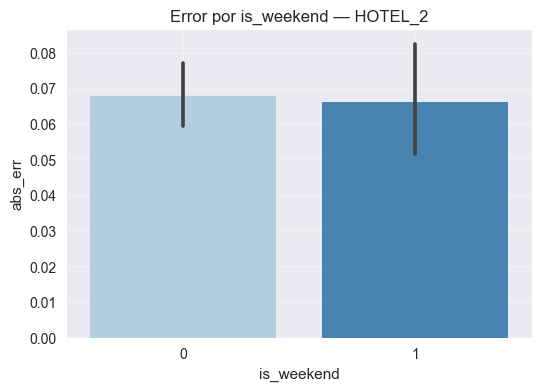


================== HOTEL_3 ==================


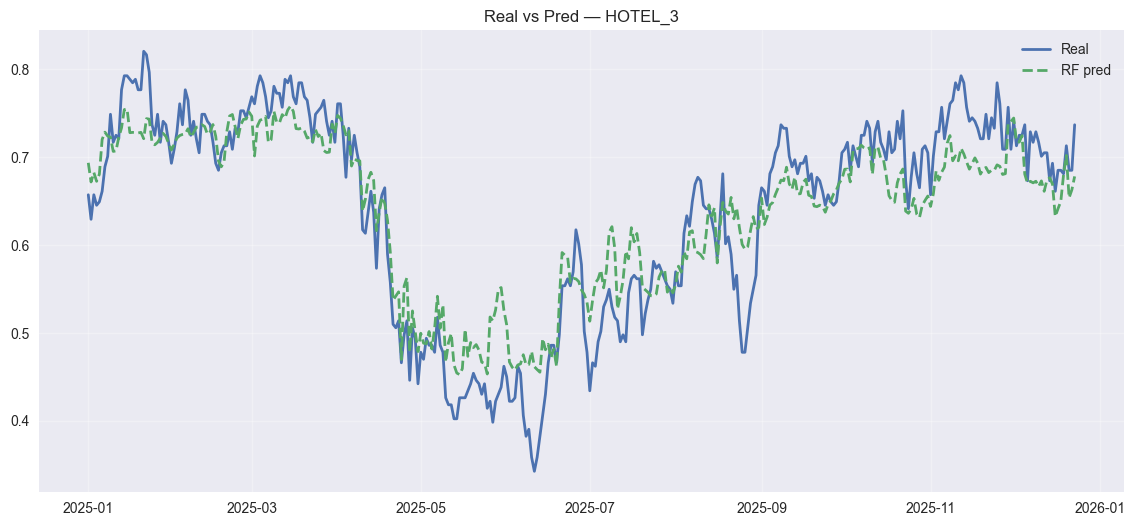

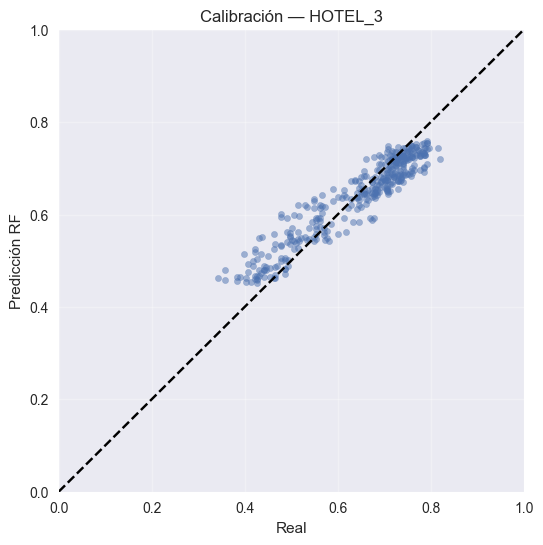

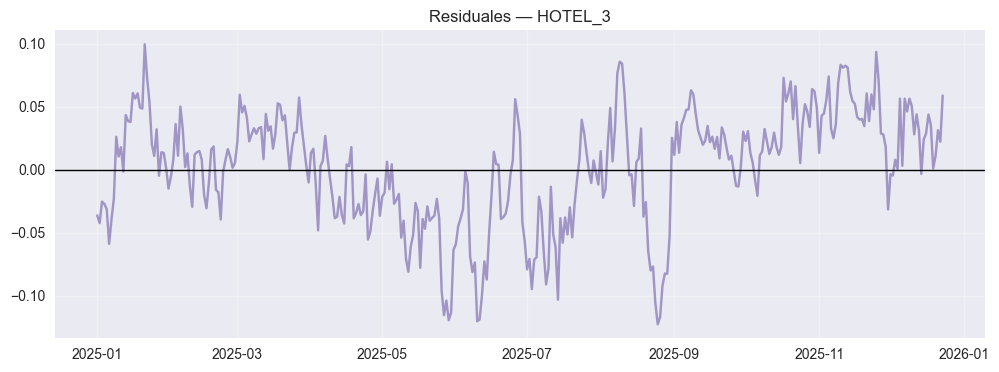

C:\Users\jorge gonzalez\AppData\Local\Temp\ipykernel_99704\3728436828.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tmp, x="is_weekend", y="abs_err", palette="Blues")


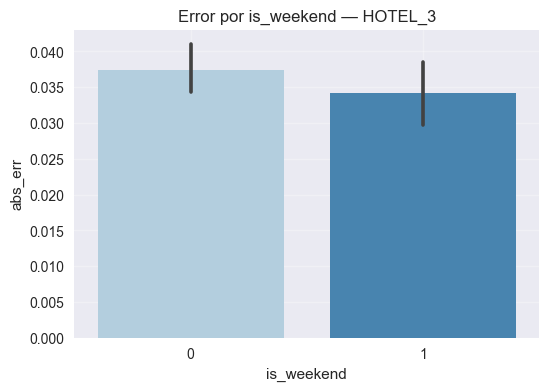

In [34]:
results               = []
feature_importances_all = []
 
for hotel in hotels:
    print(f"\n================== {hotel} ==================")
 
    df_h  = df[df["hotel"] == hotel]
    train = df_h[df_h["fecha"] < "2025-01-01"]
    test  = df_h[df_h["fecha"] >= "2025-01-01"]
 
    if len(test) == 0:
        continue
 
    feat_cols = select_causal_features(train.columns)
    X_train, y_train = train[feat_cols], train[target]
    X_test,  y_test  = test[feat_cols],  test[target]
 
    model = RandomForestRegressor(
        n_estimators=300, max_depth=12,
        min_samples_leaf=3, random_state=42, n_jobs=-1
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
 
    mae  = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mape = np.mean(np.abs((y_test - pred) / np.maximum(1e-8, y_test))) * 100
 
    results.append({"hotel": hotel, "modelo": "RandomForest",
                    "MAE": mae, "RMSE": rmse, "MAPE": mape})
 
    # Real vs Pred
    plt.figure(figsize=(14, 6))
    plt.plot(test["fecha"], test["ocup_total"], label="Real", linewidth=2)
    plt.plot(test["fecha"], pred, label="RF pred", linestyle="--", linewidth=2)
    plt.title(f"Real vs Pred — {hotel}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()
 
    # Calibración
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, pred, alpha=0.5, s=20)
    lims = [0, 1]
    plt.plot(lims, lims, "k--")
    plt.xlim(lims); plt.ylim(lims)
    plt.title(f"Calibración — {hotel}")
    plt.xlabel("Real"); plt.ylabel("Predicción RF")
    plt.grid(alpha=0.3)
    plt.show()
 
    # Residuales
    resid = y_test.values - pred
    plt.figure(figsize=(12, 4))
    plt.plot(test["fecha"], resid, color="C3", alpha=0.7)
    plt.axhline(0, color="k", lw=1)
    plt.title(f"Residuales — {hotel}")
    plt.grid(alpha=0.3)
    plt.show()
 
    # Error por fin de semana
    tmp = test.copy()
    tmp["abs_err"] = np.abs(tmp["ocup_total"] - pred)
    plt.figure(figsize=(6, 4))
    sns.barplot(data=tmp, x="is_weekend", y="abs_err", palette="Blues")
    plt.title(f"Error por is_weekend — {hotel}")
    plt.grid(alpha=0.3)
    plt.show()

Métricas

In [35]:
results_df = pd.DataFrame(results)
display(results_df)

,hotel,modelo,MAE,RMSE,MAPE
0,HOTEL_1,RandomForest,0.069182,0.119837,13.111639
1,HOTEL_2,RandomForest,0.067398,0.086468,9.830375
2,HOTEL_3,RandomForest,0.036515,0.045076,6.255674


Comparación de error por hotel

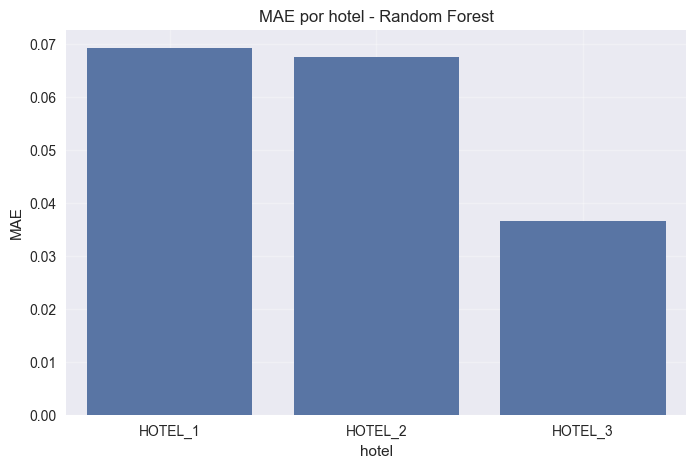

In [36]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="hotel", y="MAE")
plt.title("MAE por hotel - Random Forest")
plt.grid(alpha=0.3)
plt.show()

Guardado de métricas

In [37]:
results_df.to_csv(METRICS_DIR / "random_forest_results.csv", index=False)
print("✅ Métricas guardadas")

✅ Métricas guardadas


Predicciones

In [38]:
results_df.to_csv(METRICS_DIR / "random_forest_results.csv", index=False)
print("✅ Métricas guardadas")
 
pred_rows = []
 
for hotel in hotels:
    df_h  = df[df["hotel"] == hotel].copy()
    train = df_h[df_h["fecha"] < "2025-01-01"]
    test  = df_h[df_h["fecha"] >= "2025-01-01"]
 
    if len(test) == 0:
        continue
 
    feat_cols = select_causal_features(train.columns)
    X_train, y_train = train[feat_cols], train[target]
    X_test,  y_test  = test[feat_cols],  test[target]
 
    model = RandomForestRegressor(
        n_estimators=300, max_depth=12,
        min_samples_leaf=3, random_state=42, n_jobs=-1
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
 
    pred_rows.append(pd.DataFrame({
        "fecha": test["fecha"].values,
        "hotel": hotel,
        "modelo": "RandomForest",
        "y_real": y_test.values,
        "y_pred": pred
    }))
 
df_pred_all = pd.concat(pred_rows, ignore_index=True)
df_pred_all.to_parquet(PRED_DIR / "random_forest_predictions.parquet", index=False)
print("✅ Predicciones guardadas")

✅ Métricas guardadas
✅ Predicciones guardadas


Influencia de variables por hotel (RF)

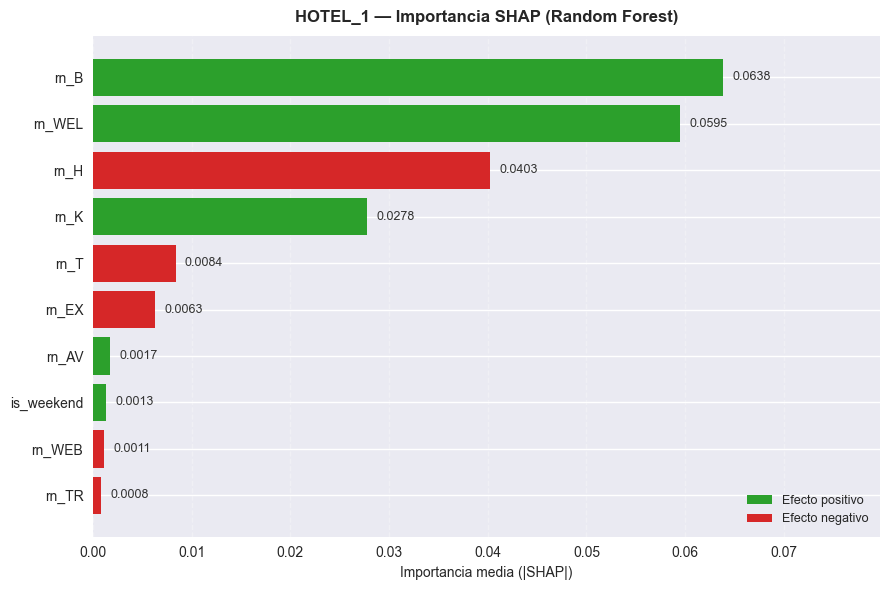

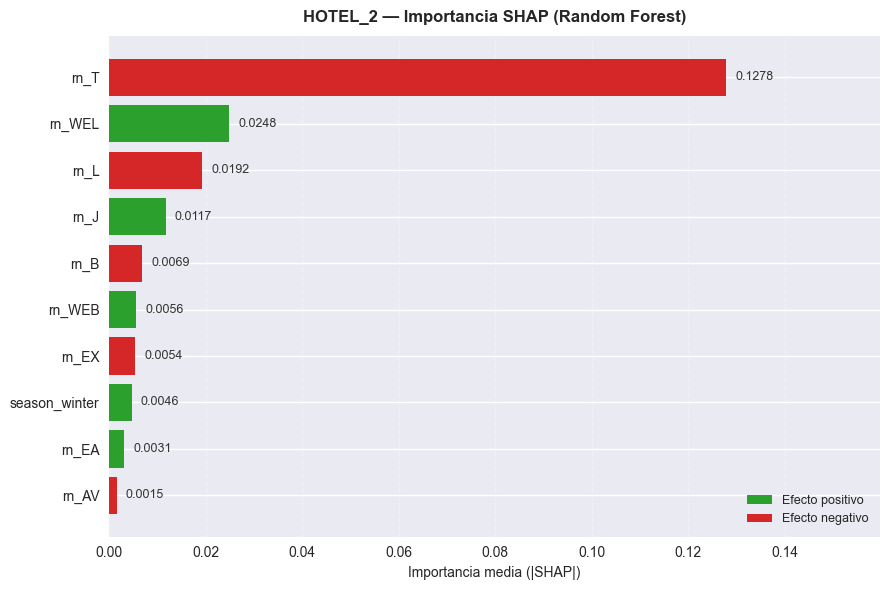

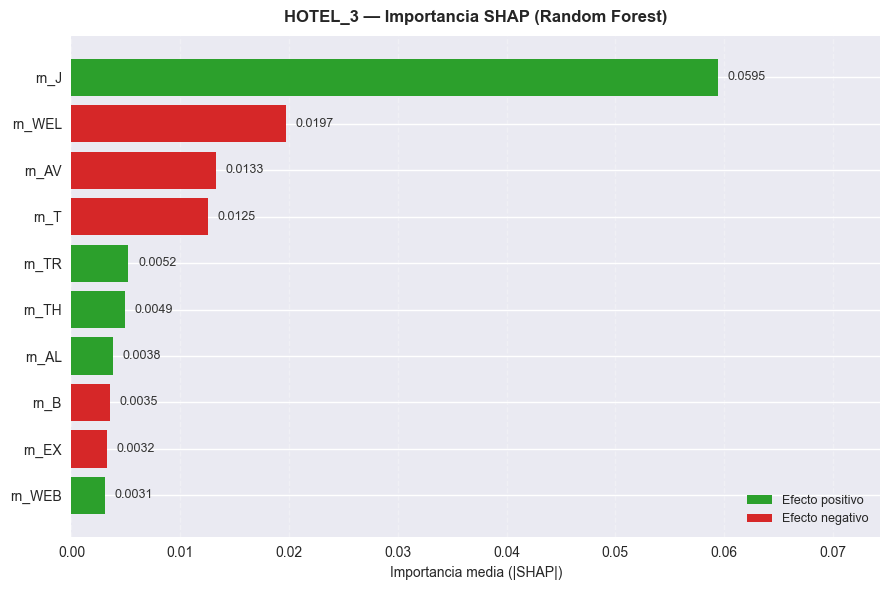

In [39]:
from matplotlib.patches import Patch

FIGS_DIR = PROJ_ROOT / "reports" / "figuras"
FIGS_DIR.mkdir(parents=True, exist_ok=True)

rf_imp_all = []

for hotel in hotels:
    df_h  = df[df["hotel"] == hotel]
    train = df_h[df_h["fecha"] < "2025-01-01"]
    test  = df_h[df_h["fecha"] >= "2025-01-01"]

    if len(test) == 0:
        continue

    feat_cols = select_causal_features(train.columns)
    X_train, y_train = train[feat_cols], train[target]
    X_test,  y_test  = test[feat_cols],  test[target]

    model = RandomForestRegressor(
        n_estimators=300, max_depth=12,
        min_samples_leaf=3, random_state=42, n_jobs=-1
    )
    model.fit(X_train, y_train)

    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_test)

    imp = pd.DataFrame({
        "feature":    X_test.columns,
        "weight":     np.mean(np.abs(shap_vals), axis=0),
        "sign_value": np.mean(shap_vals, axis=0),
    })
    imp["sign"]  = np.where(imp["sign_value"] >= 0, "positivo", "negativo")
    imp["hotel"] = hotel
    rf_imp_all.append(imp.sort_values("weight", ascending=False))

    imp_plot = imp.sort_values("weight", ascending=True).tail(10)
    colors   = imp_plot["sign"].map({"positivo": "#2ca02c", "negativo": "#d62728"})

    fig, ax = plt.subplots(figsize=(9, 6))

    bars = ax.barh(imp_plot["feature"], imp_plot["weight"], color=colors, edgecolor="none")

    for bar, val in zip(bars, imp_plot["weight"]):
        ax.text(
            bar.get_width() + imp_plot["weight"].max() * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}",
            va="center", ha="left",
            fontsize=9, color="#333333"
        )

    legend_elements = [
        Patch(facecolor="#2ca02c", label="Efecto positivo"),
        Patch(facecolor="#d62728", label="Efecto negativo"),
    ]
    ax.legend(handles=legend_elements, loc="lower right", fontsize=9, framealpha=0.8)

    ax.set_title(f"{hotel} — Importancia SHAP (Random Forest)", fontsize=12, pad=10,
    fontweight="bold")
    ax.set_xlabel("Importancia media (|SHAP|)", fontsize=10)
    ax.set_ylabel("")

    ax.set_xlim(0, imp_plot["weight"].max() * 1.25)

    ax.grid(axis="x", alpha=0.3, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()

    

    plt.show()

In [40]:
rf_imp_all = pd.concat(rf_imp_all, ignore_index=True)
rf_imp_all.to_csv(IMPORTANCE_DIR / "random_forest_importance_features.csv", index=False)
print("✅ Importancias SHAP guardadas")
display(rf_imp_all)

✅ Importancias SHAP guardadas


,feature,weight,sign_value,sign,hotel
0,rn_B,0.063802,0.038914,positivo,HOTEL_1
1,rn_WEL,0.059517,0.025016,positivo,HOTEL_1
2,rn_H,0.040259,-0.031393,negativo,HOTEL_1
3,rn_K,0.027779,0.006873,positivo,HOTEL_1
4,rn_T,0.008354,-0.006400,negativo,HOTEL_1
5,rn_EX,0.006270,-0.004663,negativo,HOTEL_1
6,rn_AV,0.001728,0.000722,positivo,HOTEL_1
7,is_weekend,0.001304,0.000151,positivo,HOTEL_1
8,rn_WEB,0.001099,-0.000221,negativo,HOTEL_1
9,rn_TR,0.000801,-0.000758,negativo,HOTEL_1


Agrupar por familias de variables (dashboard)

In [41]:
def feature_family(name: str) -> str:
    if name.startswith("ocup_"):         return "ocupacion_hist"
    if name.startswith("rn_total"):      return "total_canal"
    if name.startswith("rn_J"):          return "J"
    if name.startswith("rn_TU"):         return "TU"
    if name.startswith("rn_WEL"):        return "WEL"
    if name.startswith("rn_B"):          return "B"
    if name.startswith("rn_"):           return "otros_canal"
    if name.startswith("share_"):        return "shares"
    if name in CALENDAR_COLS:            return "calendario"
    if name in ["stock", "adr"]:         return "hotel_info"
    return "otros"
 
rf_imp_all["family"] = rf_imp_all["feature"].apply(feature_family)
 
fam_view = (
    rf_imp_all.groupby(["hotel", "family"])["weight"].sum()
    .reset_index()
    .sort_values(["hotel", "weight"], ascending=[True, False])
)
display(fam_view)

,hotel,family,weight
5,HOTEL_1,otros_canal,0.087763
0,HOTEL_1,B,0.063802
2,HOTEL_1,WEL,0.059517
3,HOTEL_1,calendario,0.001304
4,HOTEL_1,otros,0.000987
1,HOTEL_1,J,0.000665
11,HOTEL_2,otros_canal,0.164368
8,HOTEL_2,WEL,0.024819
7,HOTEL_2,J,0.011688
6,HOTEL_2,B,0.006866


# Conclusiones — Random Forest (pipeline causal final)

## Objetivo

Evaluar el rendimiento de Random Forest para predecir la ocupación diaria utilizando únicamente **variables causales contemporáneas**:

- volúmenes reales por canal (`rn_*`)
- calendario mínimo (`is_weekend`)
- estacionalidad simplificada (`season_*`)

y explicar el comportamiento aprendido mediante **SHAP**, tanto en peso (importancia) como en signo (dirección del efecto).

---

## 1. Metodología

- Entrenamiento y evaluación por hotel con split temporal:
  - **Train < 2025-01-01**
  - **Test ≥ 2025-01-01**

- Features utilizadas:
  - `rn_*` contemporáneas (demanda real por canal)
  - `is_weekend`
  - dummies de estación `season_*` tras one-hot encoding

- Modelo:

```
RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=3)
```

- Evaluación: MAE, RMSE, MAPE, gráficas de predicción, calibración, residuales e importancia SHAP (peso + signo).

---

## 2. Resultados (Test)

| Hotel   | MAE    | RMSE   | MAPE   |
|---------|--------|--------|--------|
| Hotel 1 | 0.0692 | 0.1198 | 13.12% |
| Hotel 2 | 0.0675 | 0.0865 | 9.85%  |
| Hotel 3 | 0.0366 | 0.0451 | 6.26%  |

**Lectura rápida:**

- El Hotel 3 obtiene un rendimiento excelente (MAPE ≈ 6%) → comportamiento muy estable con canales muy influyentes.
- El Hotel 2 también logra gran precisión (MAPE ≈ 10%), coherente con su alta persistencia estructural.
- El Hotel 1, al ser urbano, muestra mayor variabilidad y ruido, pero RF mejora notablemente frente a modelos puramente temporales.

---

## 3. Importancias SHAP (peso + signo)

SHAP ofrece dos señales clave:

- `weight` → cuánto "mueve" la predicción una variable
- `sign_value` → si aumenta (+) o disminuye (−) la ocupación de media

Esto permite una lectura **causal, interpretable y honesta** del modelo.

---

### Hotel 1 — Hotel urbano (dominancia OTA)

| Variable | Peso   | Signo |
|----------|--------|-------|
| rn_B     | 0.0638 | +     |
| rn_WEL   | 0.0595 | +     |
| rn_H     | 0.0403 | −     |
| rn_K     | 0.0278 | +     |
| is_weekend | 0.0013 | +   |

**Interpretación:** el Hotel 1 depende de forma clara del mix online. Los canales B y WEL impulsan directamente la ocupación. Algunos canales secundarios introducen ruido o efectos negativos. `is_weekend` tiene un efecto leve pero positivo. RF capta muy bien la dinámica OTA.

---

### Hotel 2 — Vacacional hiperestable (canal T domina)

| Variable     | Peso   | Signo |
|--------------|--------|-------|
| rn_T        | 0.1279 | −     |
| rn_WEL       | 0.0249 | +     |
| rn_L         | 0.0192 | −     |
| rn_J         | 0.0117 | +     |
| season_winter | 0.0046 | +    |

**Interpretación — por qué T tiene peso ALTO y signo NEGATIVO:**

Este es el comportamiento típico en hoteles vacacionales con altísima persistencia:

- T es el canal estructural dominante, y por eso su peso SHAP es muy alto.
- Pero su signo medio es negativo, porque RF detecta que los días con más volumen de T coinciden con periodos donde la ocupación general del hotel es más moderada (valles, cambio de régimen, rotación de cupos), mientras que los picos suelen estar asociados al canal J u otros.

En otras palabras: **T detecta el "régimen temporal del hotel", no el valor puntual del pico diario.** Esto es completamente coherente con un hotel hiperestable y 100% basado en turoperación.

`season_*` aporta señales suaves, pero el grueso de la información viene del mix de canales.

---

### Hotel 3 — Vacacional moderado (canal J impulsor)

| Variable  | Peso   | Signo |
|-----------|--------|-------|
| rn_J      | 0.0595 | +     |
| rn_WEL    | 0.0197 | −     |
| rn_AV     | 0.0133 | −     |
| rn_T     | 0.0125 | −     |
| rn_TR / rn_TH / rn_AL | 0.004–0.005 | + |

**Interpretación:** el Hotel 3 es prácticamente un "hotel J": el canal J es el driver principal con peso y signo positivo. T tiene presencia secundaria con signo negativo (efecto de mix, igual que en el Hotel 2). `season_*` aparece pero con efecto marginal. El modelo obtiene un MAPE del 6%, excepcional para este tipo de serie.

---

## 4. Gráficas clave

**Real vs Pred:** RF sigue muy bien la forma de la serie, sin los problemas de suavizado o divergencia de modelos temporales.

**Calibración:** Hotel 3 con puntos casi perfectamente alineados; Hotel 2 con muy buena calibración; Hotel 1 con buena calibración pese al ruido urbano.

**Residuales:** sin deriva, oscilan alrededor de 0 → el modelo no está sesgado.

**Error por `is_weekend`:** errores homogéneos → el fin de semana no introduce sesgos estructurales.

---

## 5. Conexión con ARIMA / SARIMA / SARIMAX

- **Hotel 1:** RF > SARIMAX > SARIMA/ARIMA → la señal de canales online potencia muchísimo la predicción.
- **Hotel 2:** SARIMAX y ARIMA ya son fuertes por la persistencia, pero RF capta mejor el mix no lineal entre T y J.
- **Hotel 3:** RF es el mejor modelo con diferencia (MAPE = 6%) → el canal J domina y RF lo captura perfectamente.

RF demuestra el valor de las relaciones no lineales entre canales en hoteles vacacionales.

---

## 6. Conclusión final — Random Forest

Random Forest resulta ser un modelo robusto, causal, explicable, realista y superior a modelos puramente temporales:

- No requiere estacionariedad y tolera ruido, multicolinealidad y no linealidad.
- Solo usa variables disponibles el mismo día (`is_weekend` + `rn_*` + `season`).
- SHAP muestra claramente el peso real de cada canal y su dirección del efecto.
- Las métricas y gráficas concuerdan con el comportamiento hotelero real, sin sobreajuste ni fuga de información.

**Implicación final de negocio:**

- El Hotel 1 debe monitorizar y potenciar los canales OTA (B, WEL).
- Los hoteles 2 y 3 deben gestionar cupos y relación con los canales T y J, especialmente porque los patrones que RF detecta muestran que cada canal influye en momentos distintos de la temporada.
- RF permite ver, por primera vez, la **sensibilidad real de la ocupación a cada canal**, algo que los modelos temporales no pueden ofrecer.